<a href="https://colab.research.google.com/github/KaluarachchiVI/DL-project/blob/main/deep_cnn%2Bvgg16_hybrid_model_unfreeze_10layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow.keras.applications import VGG16  #pretrain model vgg16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#data preprocessing part
train_dir = "/content/drive/MyDrive/chest_xray/chest_xray/train"
val_dir   = "/content/drive/MyDrive/chest_xray/chest_xray/val"
test_dir  = "/content/drive/MyDrive/chest_xray/chest_xray/test"


train_datagen = ImageDataGenerator(rescale=1./255,rotation_range=32,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir,target_size=(224,224),batch_size=32,class_mode='binary')

val_gen = val_datagen.flow_from_directory(val_dir,target_size=(224,224),batch_size=32,class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [5]:
#define customize cnn model
def build_cnn_branch(input_layer):
    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
    x = MaxPooling2D(2,2)(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(2,2)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    return x

In [6]:
#define vgg16 model
def build_vgg_branch(input_layer):
    vgg = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)
    # Freeze all layers initially
    for layer in vgg.layers:
        layer.trainable = False

    # Unfreeze last 10 layers for fine-tuning
    for layer in vgg.layers[-10:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(vgg.output)
    return x

In [7]:
# Input layer
input_layer = Input(shape=(224,224,3))

# Get features from both branches
cnn_features = build_cnn_branch(input_layer)
vgg_features = build_vgg_branch(input_layer)

# Concatenate features
combined = Concatenate()([cnn_features, vgg_features])

# Add classification layers
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)


# Final hybrid model
hybrid_model = Model(inputs=input_layer, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
from tensorflow.keras.metrics import Precision, Recall

hybrid_model.compile(optimizer=Adam(1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy', Precision(), Recall()])

hybrid_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]

 Total params: 27,817,473 (106.12 MB)

 Trainable params: 26,672,065 (101.75 MB)

 Non-trainable params: 1,145,408 (4.37 MB)

In [9]:
history_hybrid = hybrid_model.fit(train_gen,
                                  epochs=6,
                                  validation_data=val_gen)  #hostory defines to record details with time

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 611s 4s/step - accuracy: 0.7679 - loss: 0.4571 - precision: 0.8088 - recall: 0.9028 - val_accuracy: 0.8750 - val_loss: 0.3922 - val_precision: 1.0000 - val_recall: 0.7500
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 831ms/step - accuracy: 0.9283 - loss: 0.1868 - precision: 0.9541 - recall: 0.9486 - val_accuracy: 0.8750 - val_loss: 0.2593 - val_precision: 0.8750 - val_recall: 0.8750
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 823ms/step - accuracy: 0.9445 - loss: 0.1364 - precision: 0.9646 - recall: 0.9600 - val_accuracy: 0.9375 - val_loss: 0.2253 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 4/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 839ms/step - accuracy: 0.9517 - loss: 0.1314 - precision: 0.9707 - recall: 0.9658 - val_accuracy: 0.7500 - val_loss: 0.4029 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 5/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 827ms/step - accuracy: 0.9674 - loss: 0.0890 - precision: 0.9792 - recall: 0.9768 - val_accuracy: 0.8125 - 

In [10]:
hybrid_model.save("/content/drive/MyDrive/hybrid_cnn_vgg16.h5")

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(test_dir,
                                            target_size=(224, 224),
                                            batch_size=32,
                                            class_mode='binary',
                                            shuffle=False)

# Unpack all metrics returned by evaluate
loss, acc, precision, recall = hybrid_model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Precision: {precision:.2f}")
print(f"Test Recall: {recall:.2f}")

Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 367ms/step - accuracy: 0.8978 - loss: 0.3044 - precision: 0.5341 - recall: 0.6536
Test Accuracy: 92.79%
Test Precision: 0.91
Test Recall: 0.98


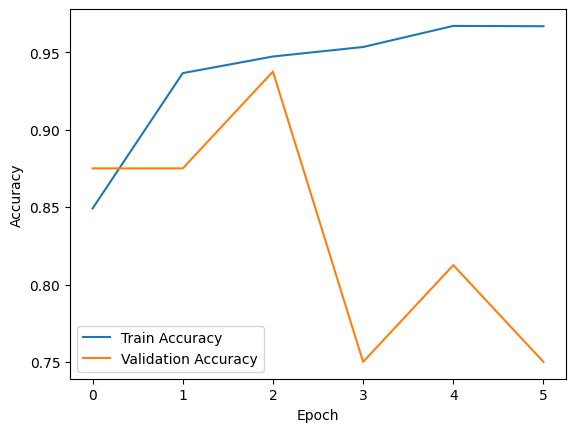

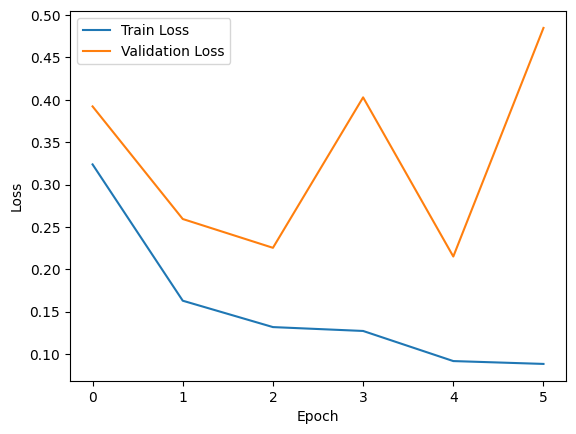

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 364ms/step
Test Precision: 0.91
Test Recall: 0.98
Test F1 Score: 0.94


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_hybrid.history['loss'], label='Train Loss')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Calculate precision, recall, and F1 score on the test set
test_predictions = hybrid_model.predict(test_gen)
test_predictions_binary = (test_predictions > 0.5).astype(int)
test_true_labels = test_gen.classes

precision = precision_score(test_true_labels, test_predictions_binary)
recall = recall_score(test_true_labels, test_predictions_binary)
f1 = f1_score(test_true_labels, test_predictions_binary)

print(f"Test Precision: {precision:.2f}")
print(f"Test Recall: {recall:.2f}")
print(f"Test F1 Score: {f1:.2f}")

# You can also visualize these metrics if you had them per epoch during training
# Since we only have them for the test set, we'll just print them.
# If you want to plot metrics per epoch, you would need to add custom callbacks during training.